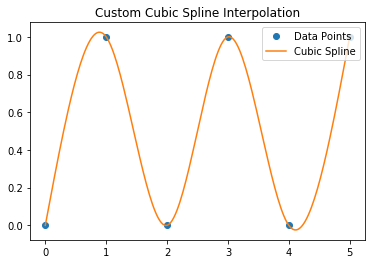

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

n = len(x)

h = np.diff(x)

A = np.zeros(n)
B = np.zeros(n)
C = np.zeros(n)
D = np.zeros(n)

B[0] = 1
B[-1] = 1
D[0] = 0
D[-1] = 0

for i in range(1, n - 1):
    A[i] = h[i - 1]
    B[i] = 2 * (h[i - 1] + h[i])
    C[i] = h[i]
    D[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

def thomas(A, B, C, D):
    n = len(D)
    c_prime = np.zeros(n)
    d_prime = np.zeros(n)

    c_prime[0] = C[0] / B[0]
    d_prime[0] = D[0] / B[0]

    for i in range(1, n):
        denom = B[i] - A[i] * c_prime[i - 1]
        c_prime[i] = C[i] / denom if i < n - 1 else 0
        d_prime[i] = (D[i] - A[i] * d_prime[i - 1]) / denom

    x = np.zeros(n)
    x[-1] = d_prime[-1]

    for i in reversed(range(n - 1)):
        x[i] = d_prime[i] - c_prime[i] * x[i + 1]

    return x

M = thomas(A, B, C, D)

def evaluate_spline(x, y, M, x_eval):
    for i in range(len(x) - 1):
        if x[i] <= x_eval <= x[i + 1]:
            h = x[i + 1] - x[i]

            term1 = M[i] * (x[i + 1] - x_eval)**3 / (6 * h)
            term2 = M[i + 1] * (x_eval - x[i])**3 / (6 * h)
            term3 = (y[i] - M[i] * h**2 / 6) * (x[i + 1] - x_eval) / h
            term4 = (y[i + 1] - M[i + 1] * h**2 / 6) * (x_eval - x[i]) / h

            return term1 + term2 + term3 + term4

x_smooth = np.linspace(x[0], x[-1], 200)
y_smooth = [evaluate_spline(x, y, M, xi) for xi in x_smooth]

plt.plot(x, y, 'o', label='Data Points')
plt.plot(x_smooth, y_smooth, '-', label='Cubic Spline')
plt.legend()
plt.title("Custom Cubic Spline Interpolation")
plt.show()

In [ ]:
#Used ChatGPT to help smooth out kinks in code, variable names, and the plot